# HBAR On-Chain Analysis — 2020 vs 2026
Comparative analysis of Hedera network activity between its first February 1st (2020) and February 1st 2026.

**Data sources:**
- BitQuery GraphQL API (volume, wallet classification, tx distribution)
- Hedera Mirror Node (active wallets count)

**Requirements:** `pip install requests pandas numpy matplotlib`

In [ ]:
# ── CELL 1 — Setup ────────────────────────────────────────────────────────────
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime, timezone, timedelta
import warnings
warnings.filterwarnings("ignore")

# ── Config ────────────────────────────────────────────────────────────────────
API_KEY      = "TU_API_KEY_AQUI"   # bitquery.io → Account → API Keys
PRECIO_2020  = 0.01                # HBAR price on 2020-02-01
PRECIO_2026  = 0.10                # HBAR price on 2026-02-01
SAVE_PATH    = r"./"               # folder to save output images

HEADERS = {
    "Content-Type": "application/json",
    "X-API-KEY": ''
}
BITQUERY_URL  = "https://graphql.bitquery.io"
MIRROR_URL    = "https://mainnet-public.mirrornode.hedera.com"

AZUL   = "#58a6ff"
NARANJA= "#f78166"
VERDE  = "#3fb950"
MORADO = "#bc8cff"

plt.style.use("dark_background")
print("Setup OK")

Setup OK


In [5]:
# ── CELL 2 — Helper functions ─────────────────────────────────────────────────
def query_bitquery(gql):
    r = requests.post(BITQUERY_URL, json={"query": gql}, headers=HEADERS)
    r.raise_for_status()
    return r.json()

print("Helpers OK")

Helpers OK


In [6]:
# ── CELL 3 — Volume, median, max, concentration (BitQuery) ────────────────────
def query_resumen(fecha, precio_hbar):
    # Total tx count
    q_count = f"""
    {{
      hedera(network: hedera) {{
        inputs(date: {{is: "{fecha}"}}, options: {{limit: 1}}) {{
          count
        }}
      }}
    }}
    """
    total_tx = query_bitquery(q_count)["data"]["hedera"]["inputs"][0]["count"]

    # Volume, median, max — grouped by currency to avoid SQL error
    q_vol = f"""
    {{
      hedera(network: hedera) {{
        inputs(
          date: {{is: "{fecha}"}}
          options: {{limit: 10000, desc: "amount"}}
        ) {{
          currency {{ symbol }}
          amount
          median_amount: amount(calculate: median)
          max_amount: amount(calculate: maximum)
        }}
      }}
    }}
    """
    raw = query_bitquery(q_vol)["data"]["hedera"]["inputs"]
    df  = pd.json_normalize(raw)
    df.rename(columns={"currency.symbol": "symbol"}, inplace=True)
    df  = df[df["symbol"] == "-"].copy()   # HBAR native only
    df["amount"]        = df["amount"]        / 1e8   # tinybars → HBAR
    df["median_amount"] = df["median_amount"] / 1e8
    df["max_amount"]    = df["max_amount"]    / 1e8

    vol_hbar = df["amount"].sum()
    mediana  = df["median_amount"].median()
    max_hbar = df["max_amount"].max()
    vol_usd  = vol_hbar * precio_hbar

    # Whale concentration — top 10 wallets by volume
    q_ballenas = f"""
    {{
      hedera(network: hedera) {{
        inputs(
          date: {{is: "{fecha}"}}
          options: {{limit: 10, desc: "amount"}}
        ) {{
          currency {{ symbol }}
          payerAccount {{ id }}
          amount
        }}
      }}
    }}
    """
    raw_b = query_bitquery(q_ballenas)["data"]["hedera"]["inputs"]
    df_b  = pd.json_normalize(raw_b)
    df_b.rename(columns={"currency.symbol": "symbol"}, inplace=True)
    df_b  = df_b[df_b["symbol"] == "-"].copy()
    df_b["amount"] = df_b["amount"] / 1e8
    concentracion = (df_b["amount"].sum() / vol_hbar * 100) if vol_hbar > 0 else 0

    return {
        "fecha":          fecha,
        "total_tx":       total_tx,
        "vol_hbar":       round(vol_hbar, 2),
        "vol_usd":        round(vol_usd, 2),
        "mediana_hbar":   round(mediana, 4),
        "max_hbar":       round(max_hbar, 2),
        "concentracion":  round(concentracion, 1),
        "precio_hbar":    precio_hbar,
    }

print("Querying 2020...")
r2020 = query_resumen("2020-02-01", PRECIO_2020)
print("Querying 2026...")
r2026 = query_resumen("2026-02-01", PRECIO_2026)

for año, d in [("2020", r2020), ("2026", r2026)]:
    print(f"\n=== {año} ===")
    for k, v in d.items():
        print(f"  {k}: {v:,}" if isinstance(v, (int, float)) else f"  {k}: {v}")

Querying 2020...
Querying 2026...

=== 2020 ===
  fecha: 2020-02-01
  total_tx: 999,055
  vol_hbar: 506,576,425.06
  vol_usd: 5,065,764.25
  mediana_hbar: 12,800.0004
  max_hbar: 347,371,334.75
  concentracion: 99.8
  precio_hbar: 0.01

=== 2026 ===
  fecha: 2026-02-01
  total_tx: 386,919
  vol_hbar: 16,589,445,650.15
  vol_usd: 1,658,944,565.02
  mediana_hbar: 64.5649
  max_hbar: 2,000,000,000.0
  concentracion: 52.1
  precio_hbar: 0.1


In [7]:
# ── CELL 4 — Active wallets (Mirror Node) ─────────────────────────────────────
# BitQuery uniq count is unreliable for Hedera — Mirror Node gives accurate data

def get_wallets_sin_filtro(fecha):
    start  = datetime.strptime(fecha, "%Y-%m-%d").replace(tzinfo=timezone.utc)
    wallets = set()
    SYSTEM_ACCOUNTS = {"0.0.98", "0.0.800", "0.0.801", "0.0.802"}

    for hora in range(0, 24, 2):
        ts_ini = f"{int((start + timedelta(hours=hora)).timestamp())}.000000000"
        ts_fin = f"{int((start + timedelta(hours=hora+2)).timestamp())}.999999999"

        url    = f"{MIRROR_URL}/api/v1/transactions"
        params = {
            "timestamp": [f"gte:{ts_ini}", f"lte:{ts_fin}"],
            "limit": 100,
            "order": "asc"
        }
        paginas = 0
        while paginas < 50:   # ~5000 tx per window
            r    = requests.get(url, params=params)
            data = r.json()
            txs  = data.get("transactions", [])
            if not txs:
                break
            for tx in txs:
                tid   = tx.get("transaction_id", "")
                payer = tid.split("-")[0] if "-" in tid else tid.split("@")[0]
                if payer:
                    wallets.add(payer)
                for transfer in tx.get("transfers", []):
                    cuenta = transfer.get("account", "")
                    if cuenta and cuenta not in SYSTEM_ACCOUNTS:
                        wallets.add(cuenta)
            next_link = data.get("links", {}).get("next")
            if not next_link:
                break
            url    = f"{MIRROR_URL}{next_link}"
            params = {}
            paginas += 1

        print(f"  {fecha} — Hora {hora:02d}h — wallets acumuladas: {len(wallets):,}")

    return len(wallets)

print("Calculando wallets 2020 (~1 min)...")
w2020 = get_wallets_sin_filtro("2020-02-01")
print(f"Wallets activas 2020: {w2020:,}")

print("\nCalculando wallets 2026 (~1 min)...")
w2026 = get_wallets_sin_filtro("2026-02-01")
print(f"Wallets activas 2026: {w2026:,}")

Calculando wallets 2020 (~1 min)...
  2020-02-01 — Hora 00h — wallets acumuladas: 60
  2020-02-01 — Hora 02h — wallets acumuladas: 62
  2020-02-01 — Hora 04h — wallets acumuladas: 62
  2020-02-01 — Hora 06h — wallets acumuladas: 64
  2020-02-01 — Hora 08h — wallets acumuladas: 68
  2020-02-01 — Hora 10h — wallets acumuladas: 69
  2020-02-01 — Hora 12h — wallets acumuladas: 72
  2020-02-01 — Hora 14h — wallets acumuladas: 82
  2020-02-01 — Hora 16h — wallets acumuladas: 85
  2020-02-01 — Hora 18h — wallets acumuladas: 85
  2020-02-01 — Hora 20h — wallets acumuladas: 86
  2020-02-01 — Hora 22h — wallets acumuladas: 91
Wallets activas 2020: 91

Calculando wallets 2026 (~1 min)...
  2026-02-01 — Hora 00h — wallets acumuladas: 288
  2026-02-01 — Hora 02h — wallets acumuladas: 457
  2026-02-01 — Hora 04h — wallets acumuladas: 589
  2026-02-01 — Hora 06h — wallets acumuladas: 704
  2026-02-01 — Hora 08h — wallets acumuladas: 819
  2026-02-01 — Hora 10h — wallets acumuladas: 908
  2026-02-01 —

In [8]:
# ── CELL 5 — Top 30 wallets + classification (BitQuery) ───────────────────────
def query_wallets(fecha):
    q = f"""
    {{
      hedera(network: hedera) {{
        inputs(
          date: {{is: "{fecha}"}}
          options: {{limit: 30, desc: "amount"}}
        ) {{
          payerAccount {{ id }}
          currency {{ symbol }}
          amount
          count
          median_amount: amount(calculate: median)
        }}
      }}
    }}
    """
    raw = query_bitquery(q)["data"]["hedera"]["inputs"]
    df  = pd.json_normalize(raw)
    df.rename(columns={"payerAccount.id": "address", "currency.symbol": "symbol"}, inplace=True)
    df  = df[df["symbol"] == "-"].copy()
    df["amount"]        = df["amount"]        / 1e8
    df["median_amount"] = df["median_amount"] / 1e8
    return df

def clasificar_wallet(row):
    if row["count"] < 20 and row["median_amount"] > 500000:
        return "Institutional"
    elif row["count"] > 500 and row["median_amount"] < 500:
        return "Market Maker / Bot"
    else:
        return "Mixed / Gateway"

print("Querying top wallets 2020...")
wallets_2020 = query_wallets("2020-02-01")
print("Querying top wallets 2026...")
wallets_2026 = query_wallets("2026-02-01")

wallets_2020["tipo"] = wallets_2020.apply(clasificar_wallet, axis=1)
wallets_2026["tipo"] = wallets_2026.apply(clasificar_wallet, axis=1)

print("\n2020:", wallets_2020["tipo"].value_counts().to_dict())
print("2026:", wallets_2026["tipo"].value_counts().to_dict())

Querying top wallets 2020...
Querying top wallets 2026...

2020: {'Mixed / Gateway': 21, 'Market Maker / Bot': 5, 'Institutional': 4}
2026: {'Institutional': 27, 'Mixed / Gateway': 3}


In [14]:
# ── CELL 6 — Tx distribution by size (BitQuery) ───────────────────────────────
# Thresholds as floats in tinybars (1 HBAR = 100,000,000 tinybars)
# BitQuery requires currency { symbol } to avoid GROUP BY SQL error
# Filtering HBAR native (symbol == "-") in Python after the call

def query_rangos(fecha):
    rangos_def = [
        ("micro",  None,             1000000.0),
        ("small",  1000000.0,        100000000.0),
        ("medium", 100000000.0,      10000000000.0),
        ("large",  10000000000.0,    1000000000000.0),
        ("whale",  1000000000000.0,  None),
    ]

    resultado = {}

    for nombre, gteq, lt in rangos_def:
        if gteq is not None and lt is not None:
            filtro = f"amount: {{gteq: {gteq}, lt: {lt}}}"
        elif gteq is None:
            filtro = f"amount: {{lt: {lt}}}"
        else:
            filtro = f"amount: {{gteq: {gteq}}}"

        q = f"""
        {{
          hedera(network: hedera) {{
            inputs(
              date: {{is: "{fecha}"}}
              {filtro}
              options: {{limit: 100}}
            ) {{
              currency {{ symbol }}
              count
              amount
            }}
          }}
        }}
        """
        raw = query_bitquery(q)
        if "data" in raw and raw["data"]["hedera"]["inputs"]:
            df = pd.json_normalize(raw["data"]["hedera"]["inputs"])
            df.rename(columns={"currency.symbol": "symbol"}, inplace=True)
            df = df[df["symbol"] == "-"].copy()
            resultado[nombre]          = df["count"].sum()
            resultado[f"vol_{nombre}"] = df["amount"].sum() / 1e8
        else:
            print(f"  Error en rango {nombre}:", raw.get("errors", ["?"])[0].get("message", "?"))
            resultado[nombre]          = 0
            resultado[f"vol_{nombre}"] = 0

    return resultado

print("Querying tx distribution 2020...")
rangos_2020 = query_rangos("2020-02-01")
print("Rangos 2020:", rangos_2020)

print("\nQuerying tx distribution 2026...")
rangos_2026 = query_rangos("2026-02-01")
print("Rangos 2026:", rangos_2026)

Querying tx distribution 2020...
Rangos 2020: {'micro': 998747, 'vol_micro': 2397.44434503, 'small': 75, 'vol_small': 21.24523647, 'medium': 106, 'vol_medium': 568.57893463, 'large': 38, 'vol_large': 107791.53946617, 'whale': 89, 'vol_whale': 506465646.2518117}

Querying tx distribution 2026...
Rangos 2026: {'micro': 4206, 'vol_micro': 3.30838486, 'small': 62802, 'vol_small': 12519.10663332, 'medium': 8358, 'vol_medium': 215004.756591, 'large': 27440, 'vol_large': 47516530.3812806, 'whale': 2537, 'vol_whale': 10504799890.768724}


In [15]:
# ── CELL 7 — Build final summary ──────────────────────────────────────────────
resumen = {
    "2020": {
        **r2020,
        "wallets_unicas": w2020,
        "tx_por_wallet":  round(r2020["total_tx"] / w2020, 1) if w2020 > 0 else 0,
    },
    "2026": {
        **r2026,
        "wallets_unicas": w2026,
        "tx_por_wallet":  round(r2026["total_tx"] / w2026, 1) if w2026 > 0 else 0,
    }
}

print("=" * 45)
for año, d in resumen.items():
    print(f"\n=== {año} ===")
    for k, v in d.items():
        print(f"  {k}: {v:,}" if isinstance(v, (int, float)) else f"  {k}: {v}")
print("=" * 45)


=== 2020 ===
  fecha: 2020-02-01
  total_tx: 999,055
  vol_hbar: 506,576,425.06
  vol_usd: 5,065,764.25
  mediana_hbar: 12,800.0004
  max_hbar: 347,371,334.75
  concentracion: 99.8
  precio_hbar: 0.01
  wallets_unicas: 91
  tx_por_wallet: 10,978.6

=== 2026 ===
  fecha: 2026-02-01
  total_tx: 386,919
  vol_hbar: 16,589,445,650.15
  vol_usd: 1,658,944,565.02
  mediana_hbar: 64.5649
  max_hbar: 2,000,000,000.0
  concentracion: 52.1
  precio_hbar: 0.1
  wallets_unicas: 1,279
  tx_por_wallet: 302.5


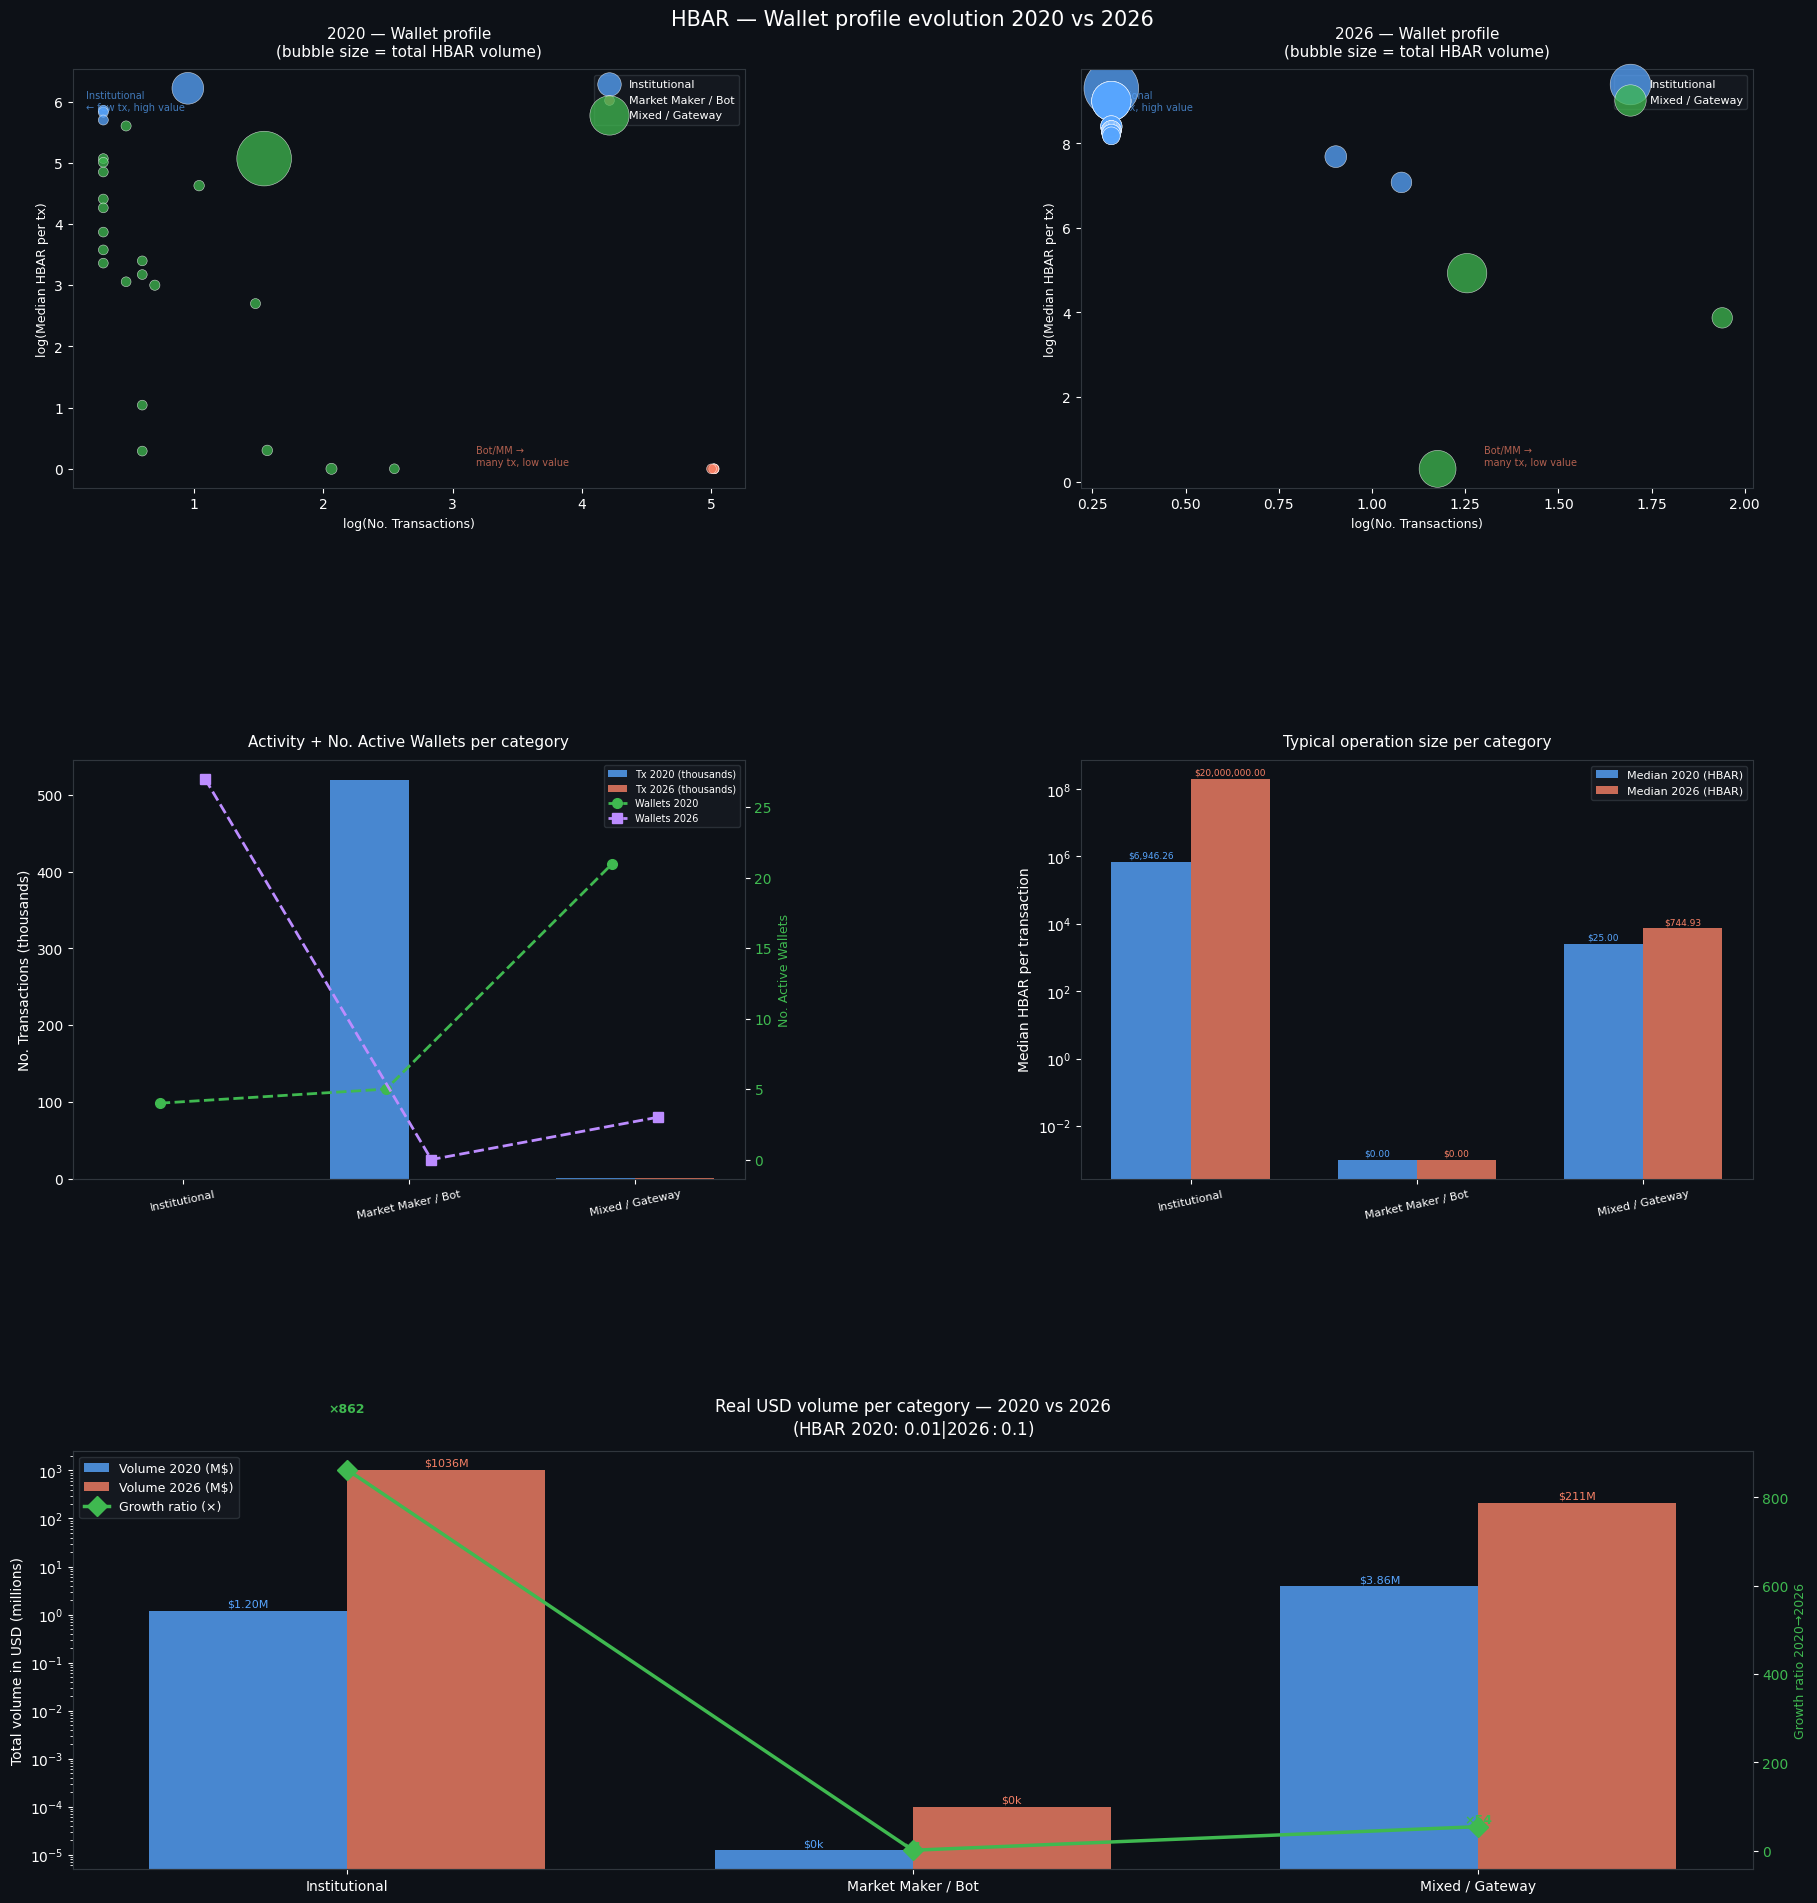

Saved: hbar_wallets_2020_2026.png


In [16]:
# ── CELL 8 — Wallet profile chart (bubble + activity + volume) ────────────────
colores_tipo = {
    "Institutional":      AZUL,
    "Market Maker / Bot": NARANJA,
    "Mixed / Gateway":    VERDE
}
tipos = ["Institutional", "Market Maker / Bot", "Mixed / Gateway"]
x = np.arange(len(tipos))
w = 0.35

def metricas(df_w, precio):
    res = {}
    for t in tipos:
        g = df_w[df_w["tipo"] == t]
        vol = g["amount"].sum() / 1e6 if len(g) else 0.001
        res[t] = {
            "n_wallets": len(g),
            "vol_total": vol,
            "tx_total":  g["count"].sum() if len(g) else 0.001,
            "mediana":   g["median_amount"].median() if len(g) else 0.001,
            "vol_usd":   vol * precio * 1e6,
        }
    return res

m2020 = metricas(wallets_2020, PRECIO_2020)
m2026 = metricas(wallets_2026, PRECIO_2026)

fig = plt.figure(figsize=(20, 20))
fig.patch.set_facecolor("#0d1117")
gs  = gridspec.GridSpec(3, 2, wspace=0.5, hspace=0.65)

# ROW 1 — Bubble charts
for df_w, año, ax_pos in [(wallets_2020, "2020", gs[0,0]), (wallets_2026, "2026", gs[0,1])]:
    ax = fig.add_subplot(ax_pos)
    ax.set_facecolor("#0d1117")
    ax.spines[["top","right","left","bottom"]].set_color("#30363d")
    ax.tick_params(colors="white")
    for tipo, grupo in df_w.groupby("tipo"):
        tam = (grupo["amount"] / df_w["amount"].max() * 1500) + 50
        ax.scatter(
            np.log10(grupo["count"] + 1),
            np.log10(grupo["median_amount"] + 1),
            s=tam, c=colores_tipo[tipo], alpha=0.75,
            edgecolors="white", linewidths=0.4, label=tipo
        )
    ax.set_xlabel("log(No. Transactions)", color="white", fontsize=9)
    ax.set_ylabel("log(Median HBAR per tx)", color="white", fontsize=9)
    ax.set_title(f"{año} — Wallet profile\n(bubble size = total HBAR volume)", color="white", fontsize=11, pad=10)
    ax.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="white", fontsize=8)
    ax.text(0.02, 0.95, "Institutional\n← few tx, high value",
            transform=ax.transAxes, color=AZUL, fontsize=7, va="top", alpha=0.7)
    ax.text(0.60, 0.05, "Bot/MM →\nmany tx, low value",
            transform=ax.transAxes, color=NARANJA, fontsize=7, va="bottom", alpha=0.7)

# ROW 2 LEFT — Activity + wallets
ax4   = fig.add_subplot(gs[1,0]); ax4_r = ax4.twinx()
ax4.set_facecolor("#0d1117")
ax4.spines[["top","right","left","bottom"]].set_color("#30363d")
ax4.tick_params(colors="white")
tx_20 = [m2020[t]["tx_total"]/1e3 for t in tipos]
tx_26 = [m2026[t]["tx_total"]/1e3 for t in tipos]
nw_20 = [m2020[t]["n_wallets"] for t in tipos]
nw_26 = [m2026[t]["n_wallets"] for t in tipos]
ax4.bar(x-w/2, tx_20, w, color=AZUL,    alpha=0.8, label="Tx 2020 (thousands)")
ax4.bar(x+w/2, tx_26, w, color=NARANJA, alpha=0.8, label="Tx 2026 (thousands)")
ax4.set_xticks(x); ax4.set_xticklabels(tipos, fontsize=8, rotation=12, color="white")
ax4.set_ylabel("No. Transactions (thousands)", color="white")
ax4.set_title("Activity + No. Active Wallets per category", color="white", fontsize=11, pad=10)
ax4_r.plot(x-0.1, nw_20, color=VERDE,  marker="o", linewidth=2, markersize=7, linestyle="--", label="Wallets 2020")
ax4_r.plot(x+0.1, nw_26, color=MORADO, marker="s", linewidth=2, markersize=7, linestyle="--", label="Wallets 2026")
ax4_r.set_ylabel("No. Active Wallets", color=VERDE, fontsize=9)
ax4_r.tick_params(axis="y", labelcolor=VERDE)
ax4_r.spines[["top","right","left","bottom"]].set_color("#30363d")
l1,lb1 = ax4.get_legend_handles_labels(); l2,lb2 = ax4_r.get_legend_handles_labels()
ax4.legend(l1+l2, lb1+lb2, facecolor="#161b22", edgecolor="#30363d", labelcolor="white", fontsize=7)

# ROW 2 RIGHT — Median operation size
ax5 = fig.add_subplot(gs[1,1])
ax5.set_facecolor("#0d1117")
ax5.spines[["top","right","left","bottom"]].set_color("#30363d")
ax5.tick_params(colors="white")
med_20 = [max(m2020[t]["mediana"], 0.001) for t in tipos]
med_26 = [max(m2026[t]["mediana"], 0.001) for t in tipos]
ax5.bar(x-w/2, med_20, w, color=AZUL,    alpha=0.8, label="Median 2020 (HBAR)")
ax5.bar(x+w/2, med_26, w, color=NARANJA, alpha=0.8, label="Median 2026 (HBAR)")
ax5.set_xticks(x); ax5.set_xticklabels(tipos, fontsize=8, rotation=12, color="white")
ax5.set_ylabel("Median HBAR per transaction", color="white")
ax5.set_yscale("log")
ax5.set_title("Typical operation size per category", color="white", fontsize=11, pad=10)
ax5.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="white", fontsize=8)
for i, t in enumerate(tipos):
    ax5.text(i-w/2, med_20[i]*1.3, f"${med_20[i]*PRECIO_2020:,.2f}", ha="center", color=AZUL, fontsize=6.5)
    ax5.text(i+w/2, med_26[i]*1.3, f"${med_26[i]*PRECIO_2026:,.2f}", ha="center", color=NARANJA, fontsize=6.5)

# ROW 3 — USD volume + growth ratio
ax6   = fig.add_subplot(gs[2,:]); ax6_r = ax6.twinx()
ax6.set_facecolor("#0d1117")
ax6.spines[["top","right","left","bottom"]].set_color("#30363d")
ax6.tick_params(colors="white")
vol_20 = [m2020[t]["vol_usd"]/1e6 for t in tipos]
vol_26 = [m2026[t]["vol_usd"]/1e6 for t in tipos]
b1 = ax6.bar(x-w/2, vol_20, w, color=AZUL,    alpha=0.8, label="Volume 2020 (M$)")
b2 = ax6.bar(x+w/2, vol_26, w, color=NARANJA, alpha=0.8, label="Volume 2026 (M$)")
ax6.set_xticks(x); ax6.set_xticklabels(tipos, fontsize=10, color="white")
ax6.set_ylabel("Total volume in USD (millions)", color="white", fontsize=10)
ax6.set_yscale("log")
ax6.set_title(f"Real USD volume per category — 2020 vs 2026\n(HBAR 2020: ${PRECIO_2020} | 2026: ${PRECIO_2026})",
              color="white", fontsize=12, pad=12)
ratio = [vol_26[i]/max(vol_20[i], 0.0001) for i in range(len(tipos))]
ax6_r.plot(x, ratio, color=VERDE, marker="D", linewidth=2.5, markersize=10, label="Growth ratio (×)")
for i, r in enumerate(ratio):
    ax6_r.text(i, r*1.15, f"×{r:,.0f}", ha="center", color=VERDE, fontsize=9, fontweight="bold")
ax6_r.set_ylabel("Growth ratio 2020→2026", color=VERDE, fontsize=9)
ax6_r.tick_params(axis="y", labelcolor=VERDE)
ax6_r.spines[["top","right","left","bottom"]].set_color("#30363d")
for bar, v in zip(b1, vol_20):
    ax6.text(bar.get_x()+bar.get_width()/2, v*1.2,
             f"${v:.2f}M" if v >= 0.01 else f"${v*1000:.0f}k",
             ha="center", color=AZUL, fontsize=8)
for bar, v in zip(b2, vol_26):
    ax6.text(bar.get_x()+bar.get_width()/2, v*1.2,
             f"${v:.0f}M" if v >= 1 else f"${v*1000:.0f}k",
             ha="center", color=NARANJA, fontsize=8)
l5,lb5 = ax6.get_legend_handles_labels(); l6,lb6 = ax6_r.get_legend_handles_labels()
ax6.legend(l5+l6, lb5+lb6, facecolor="#161b22", edgecolor="#30363d", labelcolor="white", fontsize=9)

fig.suptitle("HBAR — Wallet profile evolution 2020 vs 2026", color="white", fontsize=15)
fig.subplots_adjust(top=0.95, bottom=0.05, left=0.08, right=0.92, hspace=0.65, wspace=0.5)
plt.savefig(SAVE_PATH + "hbar_wallets_2020_2026.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("Saved: hbar_wallets_2020_2026.png")

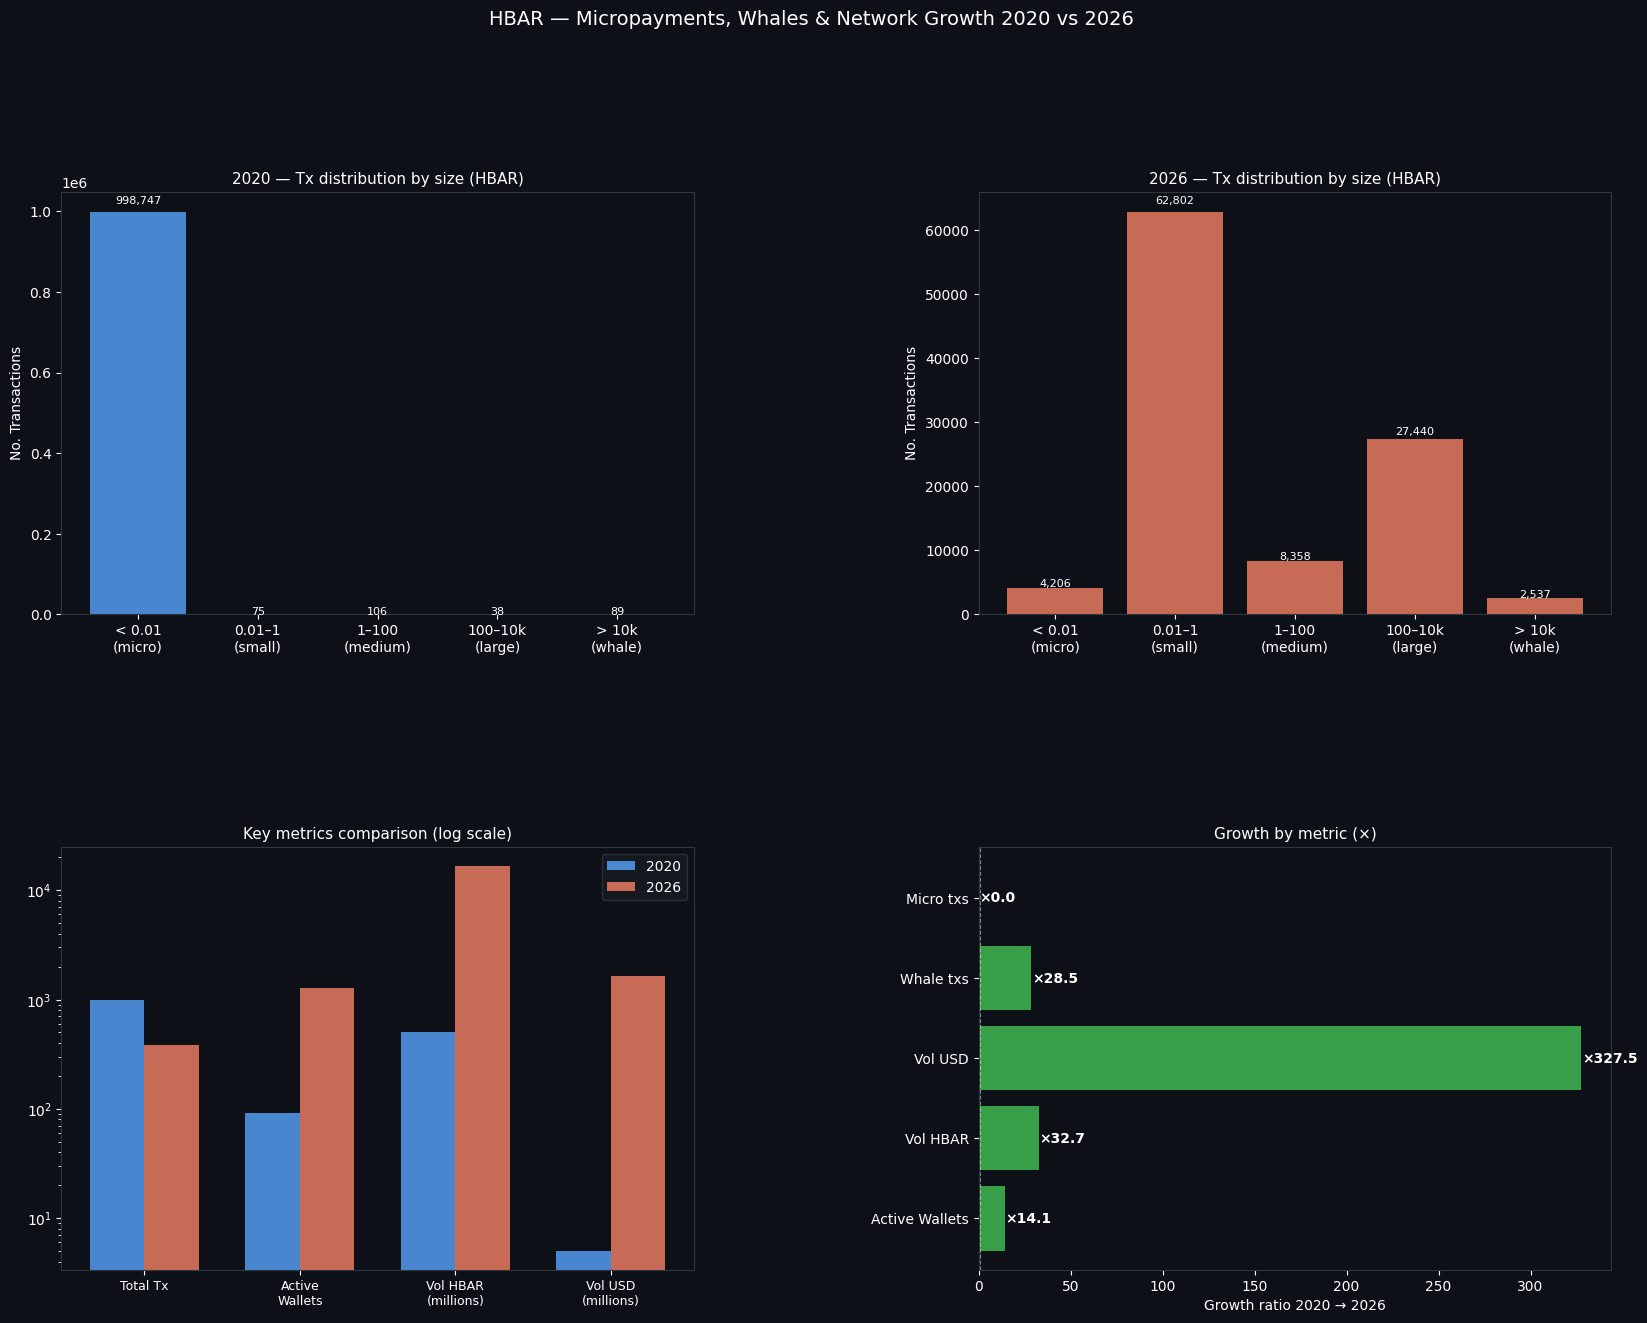

Saved: hbar_growth_2020_2026.png


In [17]:
# ── CELL 9 — Micropayments & whales + key metrics summary ─────────────────────
fig2 = plt.figure(figsize=(20, 14))
fig2.patch.set_facecolor("#0d1117")
gs2  = gridspec.GridSpec(2, 2, wspace=0.45, hspace=0.55)

labels_rangos = ["< 0.01\n(micro)", "0.01–1\n(small)", "1–100\n(medium)", "100–10k\n(large)", "> 10k\n(whale)"]
cols_count    = ["micro", "small", "medium", "large", "whale"]

# TOP LEFT — Tx distribution 2020
ax1 = fig2.add_subplot(gs2[0,0])
ax1.set_facecolor("#0d1117")
ax1.spines[["top","right","left","bottom"]].set_color("#30363d")
ax1.tick_params(colors="white")
counts_20 = [rangos_2020[c] for c in cols_count]
bars = ax1.bar(labels_rangos, counts_20, color=AZUL, alpha=0.8)
ax1.set_title("2020 — Tx distribution by size (HBAR)", color="white", fontsize=11)
ax1.set_ylabel("No. Transactions", color="white")
for bar, v in zip(bars, counts_20):
    if v > 0:
        ax1.text(bar.get_x()+bar.get_width()/2, v*1.02, f"{v:,.0f}",
                 ha="center", color="white", fontsize=8)

# TOP RIGHT — Tx distribution 2026
ax2 = fig2.add_subplot(gs2[0,1])
ax2.set_facecolor("#0d1117")
ax2.spines[["top","right","left","bottom"]].set_color("#30363d")
ax2.tick_params(colors="white")
counts_26 = [rangos_2026[c] for c in cols_count]
bars = ax2.bar(labels_rangos, counts_26, color=NARANJA, alpha=0.8)
ax2.set_title("2026 — Tx distribution by size (HBAR)", color="white", fontsize=11)
ax2.set_ylabel("No. Transactions", color="white")
for bar, v in zip(bars, counts_26):
    if v > 0:
        ax2.text(bar.get_x()+bar.get_width()/2, v*1.02, f"{v:,.0f}",
                 ha="center", color="white", fontsize=8)

# BOTTOM LEFT — Key metrics comparison
ax3 = fig2.add_subplot(gs2[1,0])
ax3.set_facecolor("#0d1117")
ax3.spines[["top","right","left","bottom"]].set_color("#30363d")
ax3.tick_params(colors="white")

metricas_labels = ["Total Tx", "Active\nWallets", "Vol HBAR\n(millions)", "Vol USD\n(millions)"]
vals_20 = [
    resumen["2020"]["total_tx"] / 1e3,
    resumen["2020"]["wallets_unicas"],
    resumen["2020"]["vol_hbar"] / 1e6,
    resumen["2020"]["vol_usd"] / 1e6,
]
vals_26 = [
    resumen["2026"]["total_tx"] / 1e3,
    resumen["2026"]["wallets_unicas"],
    resumen["2026"]["vol_hbar"] / 1e6,
    resumen["2026"]["vol_usd"] / 1e6,
]
xm = np.arange(len(metricas_labels))
ax3.bar(xm-w/2, vals_20, w, color=AZUL,    alpha=0.8, label="2020")
ax3.bar(xm+w/2, vals_26, w, color=NARANJA, alpha=0.8, label="2026")
ax3.set_xticks(xm); ax3.set_xticklabels(metricas_labels, color="white", fontsize=9)
ax3.set_yscale("log")
ax3.set_title("Key metrics comparison (log scale)", color="white", fontsize=11)
ax3.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="white")

# BOTTOM RIGHT — Growth ratios horizontal bar
ax4 = fig2.add_subplot(gs2[1,1])
ax4.set_facecolor("#0d1117")
ax4.spines[["top","right","left","bottom"]].set_color("#30363d")
ax4.tick_params(colors="white")

growth_labels = ["Active Wallets", "Vol HBAR", "Vol USD", "Whale txs", "Micro txs"]
growth_vals   = [
    round(resumen["2026"]["wallets_unicas"] / max(resumen["2020"]["wallets_unicas"], 1), 1),
    round(resumen["2026"]["vol_hbar"]       / max(resumen["2020"]["vol_hbar"], 1), 1),
    round(resumen["2026"]["vol_usd"]        / max(resumen["2020"]["vol_usd"], 1), 1),
    round(rangos_2026["whale"]              / max(rangos_2020["whale"], 1), 1),
    round(rangos_2026["micro"]              / max(rangos_2020["micro"], 1), 1),
]
colors_growth = [VERDE if v >= 1 else NARANJA for v in growth_vals]
bars = ax4.barh(growth_labels, growth_vals, color=colors_growth, alpha=0.85)
for bar, v in zip(bars, growth_vals):
    ax4.text(v + 0.5, bar.get_y() + bar.get_height()/2,
             f"×{v:,.1f}", va="center", color="white", fontsize=10, fontweight="bold")
ax4.axvline(x=1, color="white", linewidth=0.8, linestyle="--", alpha=0.5)
ax4.set_xlabel("Growth ratio 2020 → 2026", color="white")
ax4.set_title("Growth by metric (×)", color="white", fontsize=11)
ax4.set_yticklabels(growth_labels, color="white")

fig2.suptitle("HBAR — Micropayments, Whales & Network Growth 2020 vs 2026",
              color="white", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(SAVE_PATH + "hbar_growth_2020_2026.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("Saved: hbar_growth_2020_2026.png")